In [1]:
# import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from stop_utils import load_zemax_wfe

# from stop_utils import logger
# logger.remove()
# _=logger.add(sys.stderr, level="DEBUG")

In [2]:
# wfe_path = "../data/zemax/wfemap17fc.txt"
wfe_path = "../data/zemax/wfemap01fc.txt"
wfe = load_zemax_wfe(wfe_path)

2025-04-20 10:49:21 | INFO     | stop_utils.converters:load_zemax_wfe:37 - Reading Zemax WFE file: ../data/zemax/wfemap01fc.txt
2025-04-20 10:49:21 | INFO     | stop_utils.converters:load_zemax_wfe:103 - Successfully loaded and converted data from ../data/zemax/wfemap01fc.txt


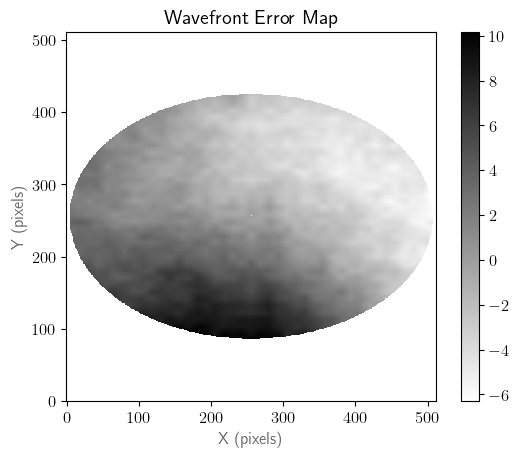

In [3]:
plt.figure()
wfe_masked = np.ma.masked_where(wfe == 0, wfe)
plt.imshow(wfe_masked, cmap="gray_r", interpolation="none", origin="lower")
plt.title("Wavefront Error Map")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.colorbar()
plt.show()

In [4]:
from stop_utils.wfe_analysis import analyze_wfe_data

In [5]:
result, params = analyze_wfe_data(
    wfe_file=Path(wfe_path), n_polynomials=36, file_format="zemax"
)

2025-04-20 10:49:21 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:213 - Analyzing WFE data from ../data/zemax/wfemap01fc.txt
2025-04-20 10:49:21 | INFO     | stop_utils.wfe_analysis:load_wfe_data:31 - Using specified Zemax file format.
2025-04-20 10:49:21 | INFO     | stop_utils.converters:load_zemax_wfe:37 - Reading Zemax WFE file: ../data/zemax/wfemap01fc.txt
2025-04-20 10:49:21 | INFO     | stop_utils.converters:load_zemax_wfe:103 - Successfully loaded and converted data from ../data/zemax/wfemap01fc.txt
2025-04-20 10:49:24 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:240 - Analysis complete - RMS error: 0.37 nm


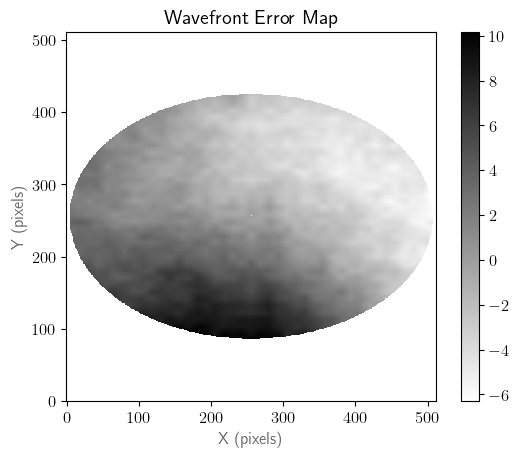

In [6]:
plt.figure()
plt.imshow(result.raw, cmap="gray_r", interpolation="none", origin="lower")
plt.title("Wavefront Error Map")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.colorbar()
plt.show()

In [7]:
from stop_utils.visualization import plot_wfe_data

In [8]:
# from photutils.aperture import EllipticalAperture

# aperture = EllipticalAperture(
#     (params.x0, params.y0), params.a, params.b, theta=params.theta
# )

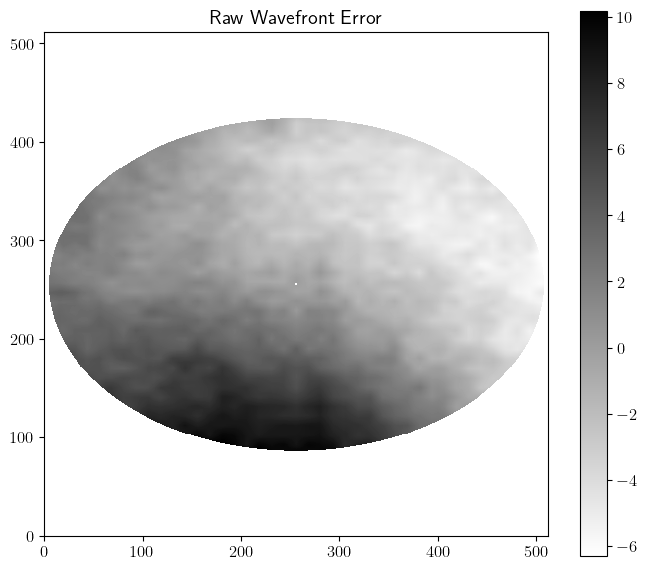

In [9]:
plot_wfe_data(
    result.raw,
    aperture=None,
    title="Raw Wavefront Error",
    output_path=None,
    zoom=1,
    cmap="gray_r",
)

In [10]:
OUTPUT_DIR = "/export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data"
output_path = f"{OUTPUT_DIR}/deleteme"

# Using Python's subprocess to run the shell command
from subprocess import run
run(["stop-utils", "analyze", wfe_path, output_path, "-n", "36", "-f", "zemax"], check=True)

⠙  Analyzing   

2025-04-20 10:49:26 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:213 - Analyzing WFE data from ../data/zemax/wfemap01fc.txt
2025-04-20 10:49:26 | INFO     | stop_utils.wfe_analysis:load_wfe_data:31 - Using specified Zemax file format.
2025-04-20 10:49:26 | INFO     | stop_utils.converters:load_zemax_wfe:37 - Reading Zemax WFE file: ../data/zemax/wfemap01fc.txt
2025-04-20 10:49:26 | INFO     | stop_utils.converters:load_zemax_wfe:103 - Successfully loaded and converted data from ../data/zemax/wfemap01fc.txt


⠏  Plotting    

2025-04-20 10:49:29 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:240 - Analysis complete - RMS error: 0.37 nm
2025-04-20 10:49:29 | INFO     | stop_utils.visualization:generate_plots:116 - Generating plots in /export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme with format=png
2025-04-20 10:49:29 | INFO     | stop_utils.visualization:generate_plots:133 - Calculated zoom factor: 1


⠸  Plotting    

Analysis complete!
  Polynomial Coefficients (standard ordering, normalize = False)  
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Mode ┃ Orthonormal Coefficient (nm) ┃ Zernike Coefficient (nm) ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  0   │                        0.344 │                    1.654 │
│  1   │                       -2.240 │                   -2.407 │
│  2   │                       -2.833 │                    6.414 │
│  3   │                       -0.979 │                   -7.025 │
│  4   │                        0.675 │                    2.826 │
│  5   │                        0.084 │                    1.866 │
│  6   │                        0.063 │                    8.431 │
│  7   │                        0.037 │                   -3.063 │
│  8   │                        0.672 │                    8.102 │
│  9   │                        0.187 │                   -6.133 │
│  10  │                  

2025-04-20 10:49:31 | INFO     | stop_utils.visualization:generate_plots:184 - All plots generated successfully
2025-04-20 10:49:31 | SUCCESS  | stop_utils.cli:run_analysis:172 - Analysis completed successfully
2025-04-20 10:49:31 | INFO     | stop_utils.cli:run_analysis:180 - Results:
  Raw WFE RMS: 3.89
  Fit WFE RMS: 3.87
  Fit WFE RMS (-PTT): 1.40
  Fit WFE RMS (-PTTF): 1.00
  Residual RMS: 0.37 nm
  Residual PTP: 3.01 nm

Ellipse parameters:
  Center: (256.0, 255.1)
  Semi-axes: (251.5, 169.3)
  Angle: 3.142 rad
2025-04-20 10:49:31 | INFO     | stop_utils.cli:run_analysis:202 - Output files:
  Plots: /export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme
  Coefficients: /export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme/polynomial_coefficients.json


CompletedProcess(args=['stop-utils', 'analyze', '../data/zemax/wfemap01fc.txt', '/export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme', '-n', '36', '-f', 'zemax'], returncode=0)

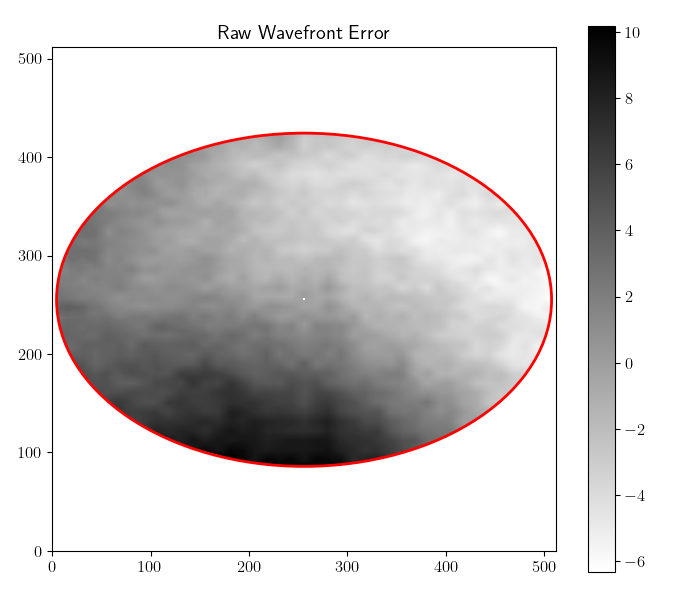

In [11]:
# open the raw wfe file map in the output directory
wfe_raw_file = Path(output_path) / "wfe_raw.png"
from PIL import Image
from IPython.display import display
img = Image.open(wfe_raw_file)
display(img)

In [12]:
# import os
# import glob
# from subprocess import run

# BASE_DIR = "/export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/"
# INPUT_DIR = os.path.join(BASE_DIR, "WavefrontOutputs_20250419")
# OUTPUT_DIR = os.path.join(BASE_DIR, "Decomposition_20250419")

# # Loop through all txt files in the input directory
# for input_file in glob.glob(os.path.join(INPUT_DIR, "*.txt")):
#     # Get the base filename without extension
#     filename = os.path.basename(input_file).replace(".txt", "")

#     # Create output directory path
#     output_path = os.path.join(OUTPUT_DIR, filename)

#     # Run stop-utils analyze command for each file
#     run(["stop-utils", "analyze", input_file, output_path, "-n", "36", "-f", "zemax"], check=True)

In [13]:
# filename, wfe_path, input_file

In [14]:
# # open the raw wfe file map in the output directory
# wfe_raw_file = Path(output_path) / "wfe_raw.png"
# from PIL import Image
# from IPython.display import display
# img = Image.open(wfe_raw_file)
# display(img)